In [ ]:
#importing the necessary libraries 
import os
import librosa
import numpy as np
import pandas as pd
from pydub import AudioSegment
import IPython
from scipy.io import wavfile
import scipy.signal
import matplotlib.pyplot as plt
%matplotlib inline
import time
import soundfile as sf
from datetime import timedelta as td
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn import metrics
import seaborn as sns

In [2]:
#functions needed to reduce gaussian noise in audio and increase the signal to noise ratio
def fftnoise(f):
    f = np.array(f, dtype="complex")
    Np = (len(f) - 1) // 2
    phases = np.random.rand(Np) * 2 * np.pi
    phases = np.cos(phases) + 1j * np.sin(phases)
    f[1 : Np + 1] *= phases
    f[-1 : -1 - Np : -1] = np.conj(f[1 : Np + 1])
    return np.fft.ifft(f).real


def band_limited_noise(min_freq, max_freq, samples=1024, samplerate=1):
    freqs = np.abs(np.fft.fftfreq(samples, 1 / samplerate))
    f = np.zeros(samples)
    f[np.logical_and(freqs >= min_freq, freqs <= max_freq)] = 1
    return fftnoise(f)

def _stft(y, n_fft, hop_length, win_length):
    return librosa.stft(y=y, n_fft=n_fft, hop_length=hop_length, win_length=win_length)


def _istft(y, hop_length, win_length):
    return librosa.istft(y, hop_length, win_length)


def _amp_to_db(x):
    return librosa.core.amplitude_to_db(x, ref=1.0, amin=1e-20, top_db=80.0)


def _db_to_amp(x,):
    return librosa.core.db_to_amplitude(x, ref=1.0)


def plot_spectrogram(signal, title):
    fig, ax = plt.subplots(figsize=(20, 4))
    cax = ax.matshow(
        signal,
        origin="lower",
        aspect="auto",
        cmap=plt.cm.seismic,
        vmin=-1 * np.max(np.abs(signal)),
        vmax=np.max(np.abs(signal)),
    )
    fig.colorbar(cax)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# def plot_statistics_and_filter(mean_freq_noise, std_freq_noise, noise_thresh, smoothing_filter):
#     fig, ax = plt.subplots(ncols=2, figsize=(20, 4))
#     plt_mean, = ax[0].plot(mean_freq_noise, label="Mean power of noise")
#     plt_std, = ax[0].plot(std_freq_noise, label="Std. power of noise")
#     plt_std, = ax[0].plot(noise_thresh, label="Noise threshold (by frequency)")
#     ax[0].set_title("Threshold for mask")
#     ax[0].legend()
#     cax = ax[1].matshow(smoothing_filter, origin="lower")
#     fig.colorbar(cax)
#     ax[1].set_title("Filter for smoothing Mask")
#     plt.show()


def removeNoise(
    audio_clip,
    noise_clip,
    n_grad_freq=2,
    n_grad_time=4,
    n_fft=2048,
    win_length=2048,
    hop_length=512,
    n_std_thresh=1.5,
    prop_decrease=1.0,
    verbose=False,
    visual=False,
):
   
    if verbose:
        start = time.time()
    # STFT over noise
    noise_stft = _stft(noise_clip, n_fft, hop_length, win_length)
    noise_stft_db = _amp_to_db(np.abs(noise_stft))  # convert to dB
    # Calculate statistics over noise
    mean_freq_noise = np.mean(noise_stft_db, axis=1)
    std_freq_noise = np.std(noise_stft_db, axis=1)
    noise_thresh = mean_freq_noise + std_freq_noise * n_std_thresh
    if verbose:
        #print("STFT on noise:", td(seconds=time.time() - start))
        start = time.time()
    # STFT over signal
    if verbose:
        start = time.time()
    sig_stft = _stft(audio_clip, n_fft, hop_length, win_length)
    sig_stft_db = _amp_to_db(np.abs(sig_stft))
    if verbose:
        #print("STFT on signal:", td(seconds=time.time() - start))
        start = time.time()
    # Calculate value to mask dB to
    mask_gain_dB = np.min(_amp_to_db(np.abs(sig_stft)))
    #print(noise_thresh, mask_gain_dB)
    # Create a smoothing filter for the mask in time and frequency
    smoothing_filter = np.outer(
        np.concatenate(
            [
                np.linspace(0, 1, n_grad_freq + 1, endpoint=False),
                np.linspace(1, 0, n_grad_freq + 2),
            ]
        )[1:-1],
        np.concatenate(
            [
                np.linspace(0, 1, n_grad_time + 1, endpoint=False),
                np.linspace(1, 0, n_grad_time + 2),
            ]
        )[1:-1],
    )
    smoothing_filter = smoothing_filter / np.sum(smoothing_filter)
    # calculate the threshold for each frequency/time bin
    db_thresh = np.repeat(
        np.reshape(noise_thresh, [1, len(mean_freq_noise)]),
        np.shape(sig_stft_db)[1],
        axis=0,
    ).T
    # mask if the signal is above the threshold
    sig_mask = sig_stft_db < db_thresh
    if verbose:
        #print("Masking:", td(seconds=time.time() - start))
        start = time.time()
    # convolve the mask with a smoothing filter
    sig_mask = scipy.signal.fftconvolve(sig_mask, smoothing_filter, mode="same")
    sig_mask = sig_mask * prop_decrease
    if verbose:
        #print("Mask convolution:", td(seconds=time.time() - start))
        start = time.time()
    # mask the signal
    sig_stft_db_masked = (
        sig_stft_db * (1 - sig_mask)
        + np.ones(np.shape(mask_gain_dB)) * mask_gain_dB * sig_mask
    )  # mask real
    sig_imag_masked = np.imag(sig_stft) * (1 - sig_mask)
    sig_stft_amp = (_db_to_amp(sig_stft_db_masked) * np.sign(sig_stft)) + (
        1j * sig_imag_masked
    )
    if verbose:
        #print("Mask application:", td(seconds=time.time() - start))
        start = time.time()
    # recover the signal
    recovered_signal = _istft(sig_stft_amp, hop_length, win_length)
    recovered_spec = _amp_to_db(
        np.abs(_stft(recovered_signal, n_fft, hop_length, win_length))
    )
    if verbose:
        return recovered_signal        
    #print("Signal recovery:", td(seconds=time.time() - start))
    # if visual:
    #     plot_spectrogram(noise_stft_db, title="Noise")
    # if visual:
    #     plot_statistics_and_filter(
    #         mean_freq_noise, std_freq_noise, noise_thresh, smoothing_filter
    #     )
    # if visual:
    #     plot_spectrogram(sig_stft_db, title="Signal")
    # if visual:
    #     plot_spectrogram(sig_mask, title="Mask applied")
    # if visual:
    #     plot_spectrogram(sig_stft_db_masked, title="Masked signal")
    # if visual:
    #     plot_spectrogram(recovered_spec, title="Recovered spectrogram")
    


In [3]:
#custom function to invoke the above functions
def noise_reduce(file):
    wav_loc = file
    rate, data = wavfile.read(wav_loc)
    data = data / 32768
    noise_len = 2 # seconds
    noise = band_limited_noise(min_freq=4000, max_freq = 12000, samples=len(data), samplerate=rate)*10
    noise_clip = noise[:rate*noise_len]
    audio_clip_band_limited = data+noise
    output = removeNoise(audio_clip=audio_clip_band_limited, noise_clip=noise_clip,verbose=True,visual=True)
    sf.write(file,output,rate)
    return file


In [4]:
#function to extract and scale the mfccs features 
def extract_mfcc(file):
    y, sr= librosa.load(file)
    feature_arr=librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    scaled_feature_arr = np.mean(feature_arr.T, axis=0)
    return scaled_feature_arr



In [5]:
#function to convert various audio formats to wav format
def convert_to_wav(file_path):
    wav_file_path=""
    file_name=os.path.basename(file_path)
    new_file_path=r"C:\Users\Arun\OneDrive\Desktop\CSE\fda_jcomp\VoxCeleb_gender\wav_recordings\\"
    if(file_path.endswith(".m4a")):
        audio = AudioSegment.from_file(file_path, format="m4a")
        wav_file_path = new_file_path+file_name.split(".")[0] + ".wav"
        audio.export(wav_file_path, format="wav")
    elif(file_path.endswith(".mp4")):
        audio = AudioSegment.from_file(file_path, format="mp4")
        wav_file_path = new_file_path+file_name.split(".")[0] + ".wav"
        audio.export(wav_file_path, format="wav")
    elif(file_path.endswith(".mp3")):
        audio = AudioSegment.from_file(file_path, format="mp3")
        wav_file_path = new_file_path+file_name.split(".")[0] + ".wav"
        audio.export(wav_file_path, format="wav")
    elif(file_path.endswith(".wav")):
        wav_file_path=new_file_path+file_name
    return wav_file_path



In [10]:
#main function to create the basic dataframe
dir_path=r"C:\Users\Arun\OneDrive\Desktop\CSE\fda_jcomp\VoxCeleb_gender\mixed_audio"
os.chdir(dir_path)
initial_df=pd.DataFrame()
recording_path_arr=[]
index_arr=[]
index_var=0
for file in os.listdir():
    wav_file_path=convert_to_wav(file)
    noise_reduced_file_path=noise_reduce(wav_file_path)
    recording_path_arr.append(noise_reduced_file_path)
    scaled_feature_array=extract_mfcc(noise_reduced_file_path)
    features_df=pd.DataFrame(data=scaled_feature_array)
    features_df=features_df.transpose()
    initial_df=pd.concat([initial_df, features_df], axis=0)
    index_arr.append(index_var)
    index_var=index_var+1


initial_df=initial_df.set_index(pd.Index(index_arr))
final_df=initial_df.copy()
final_df["file path"]=recording_path_arr
print("Audio feature dataset is as follows:\n")
print(final_df)
final_df.to_excel(r"C:\Users\Arun\OneDrive\Desktop\CSE\fda_jcomp\VoxCeleb_gender\dataset\data.xlsx")
print("Done")

C:\Users\Arun\AppData\Local\Temp\ipykernel_10744\468189186.py:23: FutureWarning: Pass hop_length=512, win_length=2048 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  return librosa.istft(y, hop_length, win_length)
C:\Users\Arun\AppData\Local\Temp\ipykernel_10744\468189186.py:23: FutureWarning: Pass hop_length=512, win_length=2048 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  return librosa.istft(y, hop_length, win_length)
C:\Users\Arun\AppData\Local\Temp\ipykernel_10744\468189186.py:23: FutureWarning: Pass hop_length=512, win_length=2048 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  return librosa.istft(y, hop_length, win_length)
C:\Users\Arun\AppData\Local\Temp\ipykernel_10744\468189186.py:23: FutureWarning: Pass hop_length=512, win_length=2048 as keyword args. From version 0.10 passing these as positional arguments will result in

Audio feature dataset is as follows:

             0           1          2          3          4          5  \
0  -311.273407  133.165756 -54.854927  24.038813 -34.015923 -10.284215   
1  -394.468323  118.960327 -18.750175  43.575737 -26.838327  32.472198   
2  -288.768341  174.057114 -17.158863  45.633495  -3.474337  15.653653   
3  -228.324188  167.867004 -54.959507  32.593685  -8.189261 -10.036990   
4  -309.482819  160.455139  19.786726  23.612127  -8.425669  10.474757   
5  -255.744781  183.075912 -23.315586  42.840855 -14.144063  14.484559   
6  -177.445862  162.415283 -58.167042  46.477291  -2.718757 -18.633949   
7  -317.459656  142.529068  19.888557  32.190918   1.923065  15.340517   
8  -370.854614  135.383148 -33.156811  49.916817 -26.330324   6.365354   
9  -307.770416  176.668564 -20.827627  48.211304 -12.856310  15.253033   
10 -288.862061  157.713318  -7.819254  35.741589 -13.954190  12.151913   
11 -297.746246  130.511032 -56.951477  17.734753 -13.999377 -14.124250   


In [9]:
#scaling and preprocessing the data 
#applying PCA to reduce the dimensions of the model
sc=StandardScaler()
initial_df=pd.DataFrame(sc.fit_transform(initial_df))
pca = PCA(n_components=2)
initial_df=pd.DataFrame(pca.fit_transform(initial_df))
initial_df.to_excel(r"C:\Users\Arun\OneDrive\Desktop\CSE\fda_jcomp\VoxCeleb_gender\dataset\train_data.xlsx")

In [7]:
#defining and applying the K Means Clustering Algorithm 
km = KMeans(n_clusters=2, init='random',n_init=10, max_iter=300, tol=1e-04, random_state=0)
clusters=km.fit_predict(initial_df)
gender_arr=["Male" if element==0 else "Female" for element in clusters]
final_df["Gender"]=gender_arr
final_df.to_excel(r"C:\Users\Arun\OneDrive\Desktop\CSE\fda_jcomp\VoxCeleb_gender\dataset\data.xlsx")
print("Final Dataframe with predicted gender is as follows:\n")
print(final_df)

Final Dataframe with predicted gender is as follows:

             0           1          2          3          4          5  \
0  -312.642456  134.808243 -55.724922  24.056210 -33.333828 -11.345556   
1  -396.173645  120.553055 -18.383146  41.496849 -24.533617  31.536205   
2  -288.584717  173.752579 -16.746181  45.104233  -2.874260  15.140097   
3  -227.259277  166.642960 -54.428135  32.810139  -8.878584  -9.238848   
4  -309.387360  160.288605  19.999802  23.359039  -8.151258  10.270032   
5  -258.056976  185.907806 -24.940153  42.840660 -12.650653  12.137465   
6  -176.376404  161.255844 -57.825073  46.974297  -3.712349 -17.714830   
7  -317.806335  142.948837  19.637203  32.272011   1.910611  15.324839   
8  -370.008728  134.113129 -31.842484  48.835045 -25.889137   6.946652   
9  -308.536163  177.512360 -21.061586  47.726841 -11.872832  14.230794   
10 -289.753204  158.718552  -8.192977  35.381599 -13.067316  11.214457   
11 -298.231293  131.124084 -57.360668  17.854757 -13.78268

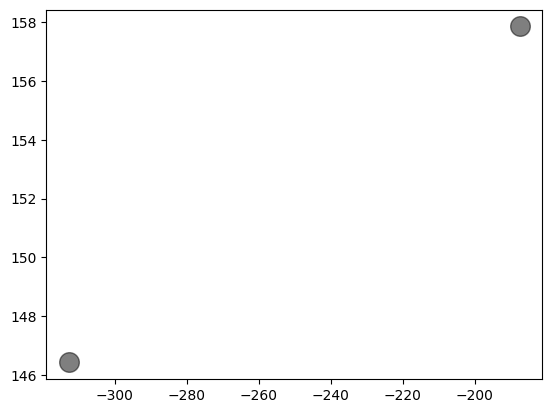

In [8]:
#plotting the clusters 
# plt.scatter(final_df[:,39], final_df[:,41], c=clusters, s=50, cmap='viridis')
centers = km.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

In [9]:
#calculate the accuracy of the model presuming that male and female audio have a different file name in the vox celeb dataset
length=len(final_df.index)
c=0
for i in final_df.index:
    path=final_df["file path"][i]
    file_name = os.path.basename(path)
    file = os.path.splitext(file_name)[0]
    gender=final_df["Gender"][i]
    dir_path=r"C:\Users\Arun\OneDrive\Desktop\CSE\fda_jcomp\VoxCeleb_gender\males"
    os.chdir(dir_path)
    for files in os.listdir():
        if (file in files):
            if(gender=="male"):
                c=c+1
                break
    dir_path=r"C:\Users\Arun\OneDrive\Desktop\CSE\fda_jcomp\VoxCeleb_gender\females"
    os.chdir(dir_path)
    for files in os.listdir():
        if (file in files):
            if(gender=="Female"):
                c=c+1
                break
accuracy=(c/length)*100
print("Accuracy of K Means Clustering algorithm: \n")
print(accuracy)
            

Accuracy of K Means Clustering algorithm: 

60.0


In [13]:
#defining and applying the Agglomerative Heirarchial Clustering Algorithm 
clustering = AgglomerativeClustering(n_clusters=2)
clusters=clustering.fit_predict(initial_df)
gender_arr=["Male" if element==1 else "Female" for element in clusters]
final_df["Gender"]=gender_arr
final_df.to_excel(r"C:\Users\Arun\OneDrive\Desktop\CSE\fda_jcomp\VoxCeleb_gender\dataset\data.xlsx")
print("Final Dataframe with predicted gender is as follows:\n")
print(final_df)

Final Dataframe with predicted gender is as follows:

             0           1          2          3          4          5  \
0  -311.273407  133.165756 -54.854927  24.038813 -34.015923 -10.284215   
1  -394.468323  118.960327 -18.750175  43.575737 -26.838327  32.472198   
2  -288.768341  174.057114 -17.158863  45.633495  -3.474337  15.653653   
3  -228.324188  167.867004 -54.959507  32.593685  -8.189261 -10.036990   
4  -309.482819  160.455139  19.786726  23.612127  -8.425669  10.474757   
5  -255.744781  183.075912 -23.315586  42.840855 -14.144063  14.484559   
6  -177.445862  162.415283 -58.167042  46.477291  -2.718757 -18.633949   
7  -317.459656  142.529068  19.888557  32.190918   1.923065  15.340517   
8  -370.854614  135.383148 -33.156811  49.916817 -26.330324   6.365354   
9  -307.770416  176.668564 -20.827627  48.211304 -12.856310  15.253033   
10 -288.862061  157.713318  -7.819254  35.741589 -13.954190  12.151913   
11 -297.746246  130.511032 -56.951477  17.734753 -13.99937

In [14]:
#calculate the accuracy of the model presuming that male and female audio have a different file name in the vox celeb dataset
length=len(final_df.index)
c=0
for i in final_df.index:
    path=final_df["file path"][i]
    file_name = os.path.basename(path)
    file = os.path.splitext(file_name)[0]
    gender=final_df["Gender"][i]
    dir_path=r"C:\Users\Arun\OneDrive\Desktop\CSE\fda_jcomp\VoxCeleb_gender\males"
    os.chdir(dir_path)
    for files in os.listdir():
        if (file in files):
            if(gender=="male"):
                c=c+1
                break
    dir_path=r"C:\Users\Arun\OneDrive\Desktop\CSE\fda_jcomp\VoxCeleb_gender\females"
    os.chdir(dir_path)
    for files in os.listdir():
        if (file in files):
            if(gender=="Female"):
                c=c+1
                break
accuracy=(c/length)*100
print("Accuracy of Heirarchial Clustering algorithm: \n")
print(accuracy)


Accuracy of Heirarchial Clustering algorithm: 

60.0
